## IMPORT LIBRARIES

In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

### LOAD DATASETS


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

### EXPLORE DATASETS
##### 1. Check shapes
##### 2. Check pixel range
##### 3.  Visualise first image

In [3]:
# CHECK SHAPES
print(X_train.shape) # (60000, 28, 28)
print(y_train.shape) # (60000,)
print(X_test.shape) # (10000, 28, 28)
print(y_test.shape) # (10000,)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
# CHECK PIXEL RANGE
print(X_train.min()) # 0
print(X_train.max()) # 255

0
255


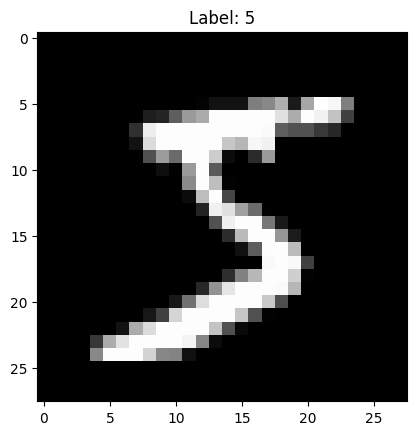

In [5]:
# VISUALIZE FIRST IMAGE
plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_train[0]}')
plt.show()

## PREPROCESS DATASETS
##### 1.# Flatten: (60000, 28, 28) fi (60000, 784)
##### 2. # Normalise: 0-255 fi 0.0-1.
##### 3. #One-hot encode labels


In [6]:
# FLATTEN
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [7]:
#NORMALISE
X_train = X_train / 255
X_test = X_test / 255
print(X_train.min()) # 0
print(X_train.max()) # 1

0.0
1.0


In [8]:
# ONE-HOT ENCODE LABELS
def one_hot(y, num_classes=10):
    # If already one-hot, just return it
    if y.ndim > 1 and y.shape[1] == num_classes:
        return y
    
    y = y.astype(int)
    m = y.shape[0]
    one_hot = np.zeros((m, num_classes))   # <-- fix here
    one_hot[np.arange(m), y] = 1
    return one_hot


In [9]:
y_train = one_hot(y_train)
y_test = one_hot(y_test)

## INITIALIZE PARAMETER 

In [10]:
# CREATE PARAMETERS 
np.random.seed(42)
W1 = np.random.randn(784,128) *  np.sqrt(2/784)
b1 = np.zeros((1,128))
print(W1.shape)
print(b1.shape)
W2 = np.random.randn(128,10) *  np.sqrt(2/128)
b2 = np.zeros((1,10))
print(W2.shape)
print(b2.shape)

(784, 128)
(1, 128)
(128, 10)
(1, 10)


## ACTIVATIONS FUNCTIONS


In [11]:
# RELU FUNCTIONS
def relu(z):
    return np.maximum(0,z)

# RELU DERIVATIVES
def relu_derivative(z):
    return (z > 0).astype(float)
# SOFTMAX FUNCTION
def softmax(z): 
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    

In [12]:
def forward(X, W1, b1, W2, b2):
    
    
# Layer 1 — linear transformation
    Z1 = X @ W1 + b1 # (m, 784) @ (784, 128) + (1, 128) = (m, 128)
# Layer 1 — activation
    A1 = relu(Z1) # (m, 128) — negatives become zero
# Layer 2 — linear transformation
    Z2 = A1 @ W2 + b2 # (m, 128) @ (128, 10) + (1, 10) = (m, 10)
# Layer 2 — activation (probabilities)
    A2 = softmax(Z2) # (m, 10) — rows sum to 1
    return Z1, A1, Z2, A2 # save all — backprop needs Z1 and A1

In [13]:
def cross_entropy(A, Y):
    m = Y.shape[0] # number of samples
    loss = -np.sum(Y * np.log(A2 + 1e-8)) / m # average cross-entropy
    return loss

In [14]:
# 1. Forward pass
Z1, A1, Z2, A2 = forward(X_train, W1, b1, W2, b2)

# 2. Compute loss
loss = cross_entropy(y_train, A2)   # y_train must be one-hot
print(f'Initial loss: {loss:.4f}')  # should be ~2.3 with random weights


Initial loss: 2.2285


In [15]:
def backward(X, Y, Z1, A1, A2, W2):
    m = X.shape[0] # number of samples
# nn OUTPUT LAYER nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
# Gradient of loss w.r.t. Z2
# Softmax + cross-entropy derivative simplifies to: prediction - truth
    dZ2 = A2 - Y # (m, 10)
# Gradient w.r.t. W2
    dW2 = A1.T @ dZ2 / m # (128, 10)
# Gradient w.r.t. b2 — sum over all samples
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m # (1, 10)
# nn HIDDEN LAYER nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
# Pass error back through W2
    dA1 = dZ2 @ W2.T # (m, 128)
# Apply ReLU derivative — gradient blocked where neuron was off
    dZ1 = dA1 * relu_derivative(Z1) # (m, 128)
# Gradient w.r.t. W1
    dW1 = X.T @ dZ1 / m # (784, 128)
# Gradient w.r.t. b1
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m # (1, 128)
    return dW1, db1, dW2, db2

Epoch   5 | Loss: 0.1205 | Accuracy: 96.7%
Epoch  10 | Loss: 0.1199 | Accuracy: 96.7%
Epoch  15 | Loss: 0.1192 | Accuracy: 96.7%
Epoch  20 | Loss: 0.1186 | Accuracy: 96.7%
Epoch  25 | Loss: 0.1179 | Accuracy: 96.8%
Epoch  30 | Loss: 0.1173 | Accuracy: 96.8%
Epoch  35 | Loss: 0.1167 | Accuracy: 96.8%
Epoch  40 | Loss: 0.1160 | Accuracy: 96.8%
Epoch  45 | Loss: 0.1154 | Accuracy: 96.8%
Epoch  50 | Loss: 0.1148 | Accuracy: 96.8%
Epoch  55 | Loss: 0.1142 | Accuracy: 96.8%
Epoch  60 | Loss: 0.1137 | Accuracy: 96.8%
Epoch  65 | Loss: 0.1131 | Accuracy: 96.9%
Epoch  70 | Loss: 0.1125 | Accuracy: 96.9%
Epoch  75 | Loss: 0.1119 | Accuracy: 96.9%
Epoch  80 | Loss: 0.1113 | Accuracy: 96.9%
Epoch  85 | Loss: 0.1108 | Accuracy: 96.9%
Epoch  90 | Loss: 0.1102 | Accuracy: 96.9%
Epoch  95 | Loss: 0.1097 | Accuracy: 97.0%
Epoch 100 | Loss: 0.1091 | Accuracy: 97.0%
Epoch 105 | Loss: 0.1086 | Accuracy: 97.0%
Epoch 110 | Loss: 0.1081 | Accuracy: 97.0%
Epoch 115 | Loss: 0.1075 | Accuracy: 97.0%
Epoch 120 |

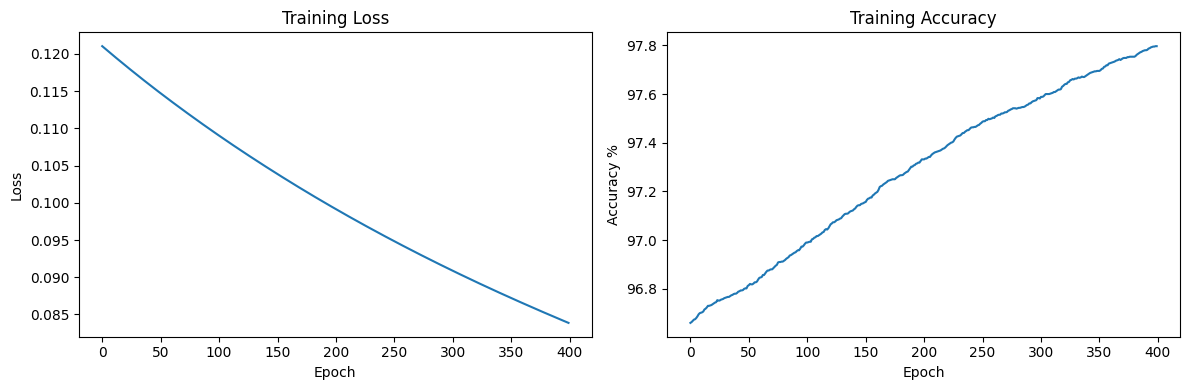

In [21]:
learning_rate = 0.46
epochs = 400
losses = []
accuracies = []
for epoch in range(epochs):
    
# 1. Forward pass
    Z1, A1, Z2, A2 = forward(X_train, W1, b1, W2, b2)
# 2. Loss
    loss = cross_entropy(A2, y_train)
    losses.append(loss)
# 3. Accuracy
 # 3. Accuracy
    preds = np.argmax(A2, axis=1)              # predicted class indices
    true_labels = np.argmax(y_train, axis=1)   # true class indices
    acc = np.mean(preds == true_labels)
    accuracies.append(acc)

# 4. Backward pass
    dW1, db1, dW2, db2 = backward(X_train, y_train, Z1, A1, A2, W2)
# 5. Update weights
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
# 6. Log progress
    if (epoch + 1) % 5 == 0:
       print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f} | Accuracy: {acc*100:.1f}%')
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax2.plot([a*100 for a in accuracies])
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
plt.tight_layout()
plt.show()

Test Accuracy: 94.48%


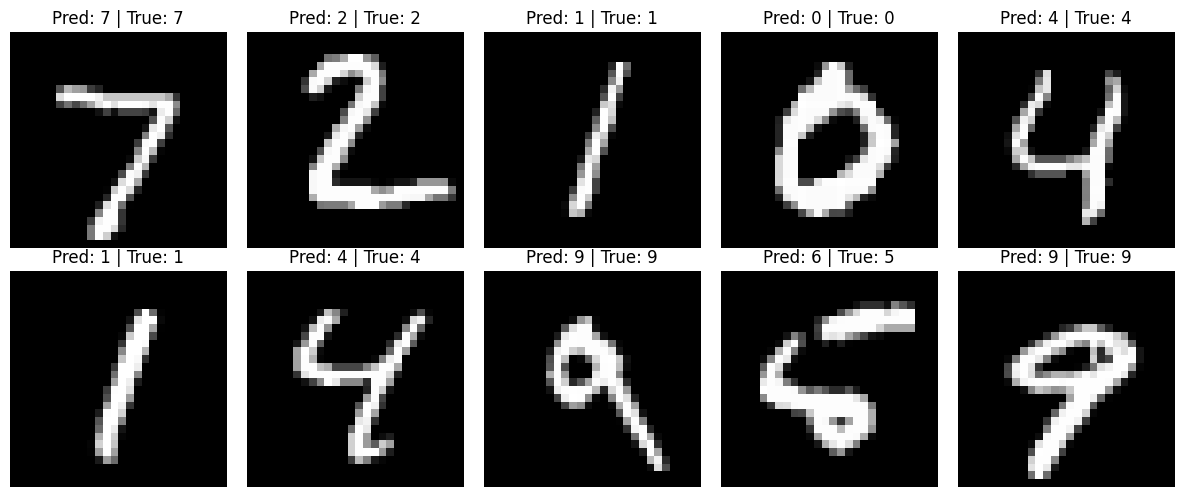

In [17]:
# Forward pass on test data — no backprop, no updates
_, _, _, A2_test = forward(X_test, W1, b1, W2, b2)

# Convert probabilities to class predictions
predictions = np.argmax(A2_test, axis=1)   # shape (10000,)
true_labels = np.argmax(y_test, axis=1)    # shape (10000,)

# Accuracy
accuracy = np.mean(predictions == true_labels)
print(f'Test Accuracy: {accuracy * 100:.2f}%')  # target: >97%

# Visualise predictions on 10 samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Pred: {predictions[i]} | True: {true_labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()
